In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
import nitools as nt
import pandas as pd


Default device set to: cuda


# define atlas for data used and ROI mask dir

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/'
model_name='NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir+model_name, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
VL_mdtb_1 = VL_mdtb_1[:28,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


In [4]:
lut_file_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Atlases/NettekovenSym32.lut'
lut = pd.read_csv(lut_file_dir, sep=' ', header=None)
# ge the parcel names from the 4th column
parcel_names = lut.iloc[:,4].values
parcel_names = parcel_names[1:]
len(parcel_names)

32

# Load data

In [5]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]



data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]




data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [6]:
data_mdtb_s1_run,info_mdtb_1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)

data_mdtb_s1_all,info_mdtb_1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_all.shape)


(24, 448, 6918)
(24, 28, 6918)


In [7]:
# make a data of shape 1 x data_mdtb_s1_all.shape[2] of 1s
ROI_mask = np.ones((data_mdtb_s1_all.shape[2]),)
ROI_indices = np.where(ROI_mask == 1)[0]



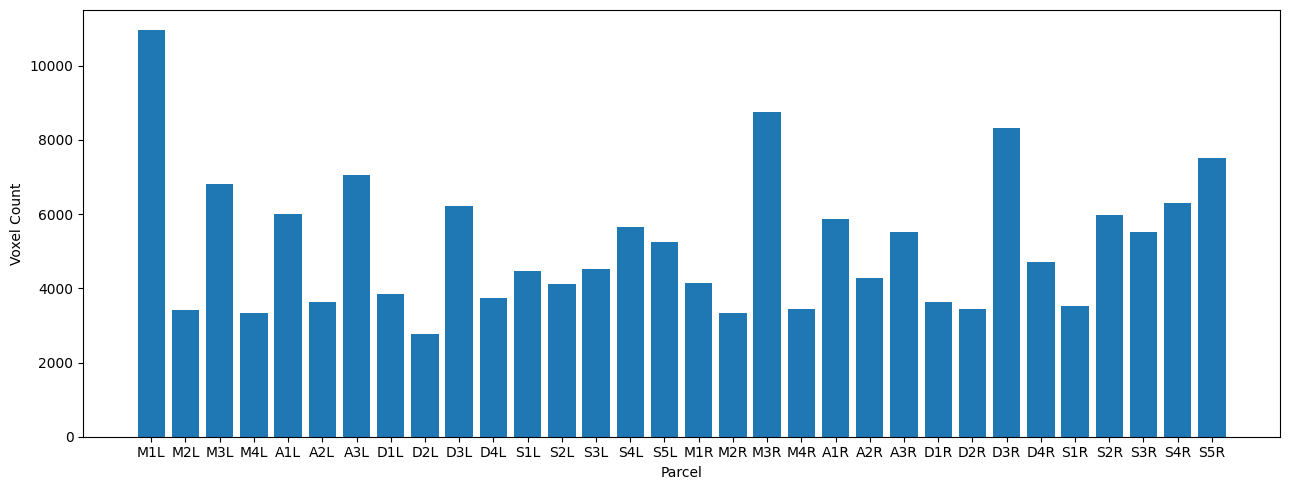

In [8]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(13, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=parcel_names)
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 8 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:8]


In [9]:
VLib = VL_mdtb_1[:,top_parcels]
vtest = VL_mdtb_2[:,top_parcels]

# Get crossvalidated second moment matrix (GLib)

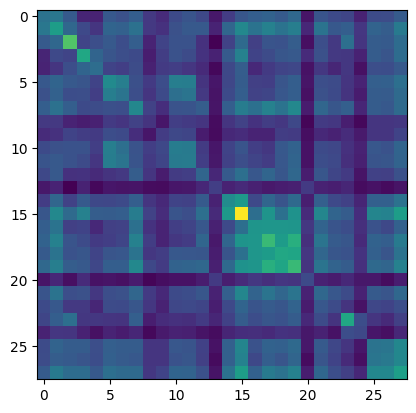

In [ ]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [22]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=1000,n_tasks=6,seed=1,replacement=True)
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
D_ev = D_ev.reset_index(drop=True)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processing combination: 350
Pro

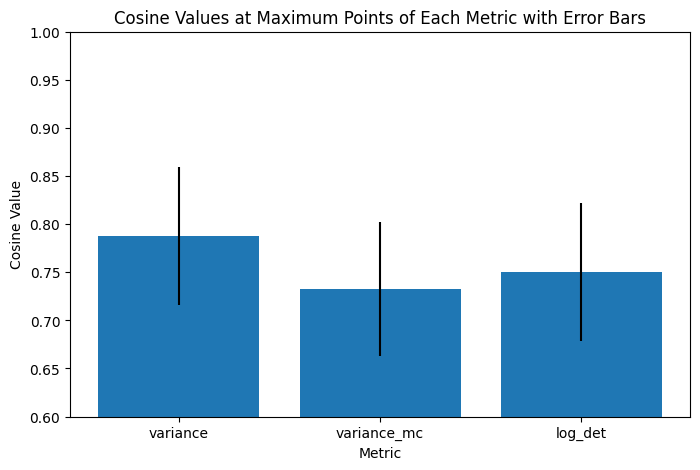

In [73]:
metrics = ["variance", "variance_mc", "log_det"]
max_indices = {metric: D_ev[metric].idxmax() for metric in metrics}

cos_values = {metric: D_ev.loc[idx, "cos"] for metric, idx in max_indices.items()}
cos_std_values = {metric: D_ev.loc[idx, "cos_std"] for metric, idx in max_indices.items()}

x_labels = list(cos_values.keys())
y_values = list(cos_values.values())
y_errors = list(cos_std_values.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(x_labels, y_values, yerr=y_errors)

plt.xlabel("Metric")
plt.ylabel("Cosine Value")
plt.title("Cosine Values at Maximum Points of Each Metric with Error Bars")
plt.ylim(0.6, 1)

# Show plot
plt.show()




# check task batteries with different sizes

In [74]:
battery_sizes = [4,6,8,10,14,18,22]

In [75]:
results_list = []
metrics = ["variance", "variance_mc", "log_det_mc"]

for i in battery_sizes:
    print(f"Processing battery size: {i}")
    
    # Generate task combinations and evaluate
    D = ut.build_combinations(G_Lib, strategy='random',n_iter=2000,n_tasks=i,seed=1,replacement=True)
    D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
    D_ev = D_ev.reset_index(drop=True)
    
    for metric in metrics:
        max_idx = D_ev[metric].idxmax()
        cos = D_ev.loc[max_idx, "cos"]
        cos_std = D_ev.loc[max_idx, "cos_std"]
        
        results_list.append({
            "battery_size": i,
            "metric": metric,
            "cos": cos,
            "cos_std": cos_std
        })
    
results_df = pd.DataFrame(results_list)



Processing battery size: 4
Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Proc

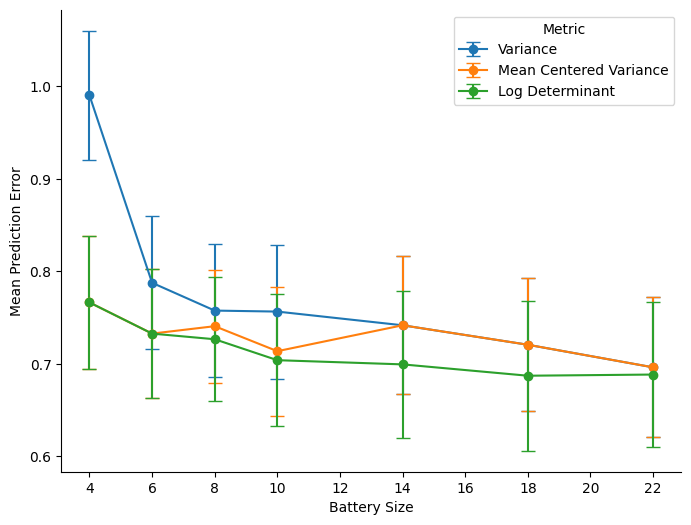

In [102]:

plt.figure(figsize=(8, 6))

# Get unique metrics
metrics = results_df["metric"].unique()

# xlabel from 4 to 22 with step 2
plt.xticks(np.arange(4, 24, 2))

# Corrected variable name: metricv_names
metricv_names = ["Variance", "Mean Centered Variance", "Log Determinant"]
metric_map = dict(zip(metrics, metricv_names))  # Mapping original metric names to new names

for metric in metrics:
    subset = results_df[results_df["metric"] == metric]
    plt.errorbar(subset["battery_size"], subset["cos"], yerr=subset["cos_std"], 
                 label=metric_map.get(metric, metric), capsize=5, marker='o', linestyle='-')

plt.xlabel("Battery Size")
plt.ylabel("Mean Prediction Error")
plt.legend(title="Metric")
sns.despine()

# Save as png
plt.savefig("mean_prediction_error_cereb.png")
plt.show()


# n parcels

In [95]:
n_parcel = [2,3,4,5,6,7,8,10,12]


In [103]:
results_list = []
total_parcel_counts = np.zeros(32)
for subject_data in data_mdtb_s1_all:
        data = subject_data[:, ROI_indices]
        
        data_projected = VL_mdtb_1.T @ data
        data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
        
        total_parcel_counts += np.sum(data_projected_onehot, axis=1)


for i in n_parcel:
    print(f"Processing n_parcel: {i}")
    
    # choose top n parcels with highest voxel counts
    top_parcels = np.argsort(total_parcel_counts)[::-1][:i]
    VLib = VL_mdtb_1[:,top_parcels]
    vtest =  VL_mdtb_2[:,top_parcels]
    D = ut.build_combinations(G_Lib, strategy='random',n_iter=1000,n_tasks=8,seed=1,replacement=True)
    D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
    D_ev = D_ev.reset_index(drop=True)

    for metric in metrics:
        max_idx = D_ev[metric].idxmax()
        cos = D_ev.loc[max_idx, "cos"]
        cos_std = D_ev.loc[max_idx, "cos_std"]
        
        results_list.append({
            "n_parcel": i,
            "metric": metric,
            "cos": cos,
            "cos_std": cos_std
        })

results_df_parcel = pd.DataFrame(results_list)




Processing n_parcel: 2
Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processi

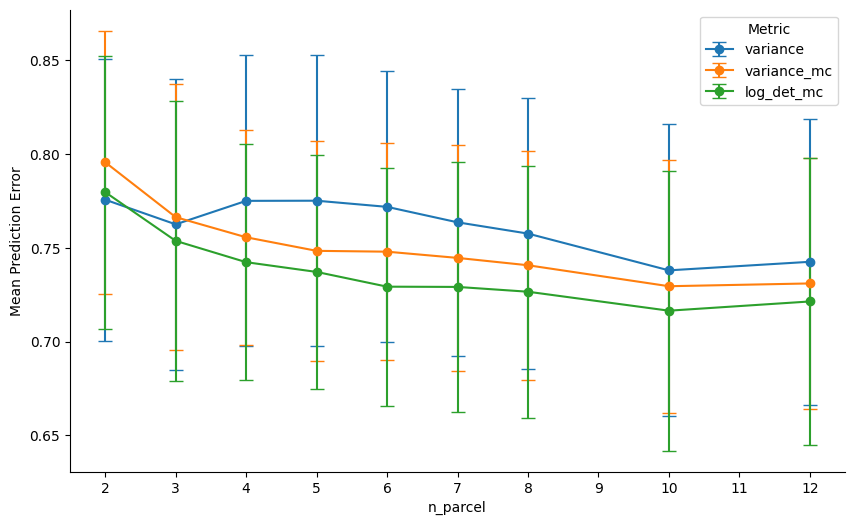

In [104]:
plt.figure(figsize=(10, 6))

# Get unique metrics
metrics = results_df_parcel["metric"].unique()

#xlabel from 4 to 22 with step 2
plt.xticks(np.arange(1, 13, 1))

# metric_names
metric_names = ["Variance", "Mean Centered Variance", "Log Determinant"]

for metric in metrics:
    subset = results_df_parcel[results_df_parcel["metric"] == metric]
    plt.errorbar(subset["n_parcel"], subset["cos"], yerr=subset["cos_std"], label=metric, capsize=5, marker='o', linestyle='-')

plt.xlabel("n_parcel")
plt.ylabel("Mean Prediction Error")
plt.legend(title="Metric")
sns.despine()
# save as pdf
plt.savefig("C:/Users/barafat/Desktop/n_parcel_vs_prediction_error.pdf")
plt.show()